# 02 · 没有动作标签，如何从奖励学会控制？

第一课你有专家动作 $a^*$。这一课没有人告诉你每一步怎么做，环境只反馈动作之后的结果和奖励。

**研究问题：在固定交互预算下，策略是否学会把摆摆起并保持向上？训练过程中的“更好”怎样变成可核验的执行结果？**

闭环：`探索收集 transition → replay buffer → SAC 更新 → checkpoint → 独立 rollout → 失效测试 → 下一轮预算实验`。
对应 quant：先定义目标与约束，在可交互的模拟市场里优化行为，再用独立初始条件和压力场景检验。此处学习的是动作策略，不是一个静态 return 预测器。

本课交付：原始交互记录、0/2k/10k 步策略、经验回放检查、配对评测、动画和一页复盘。
默认 Mac CPU；读取低维状态；使用 Stable-Baselines3 的实际 SAC 实现。这是机制练习，不是论文分数复现。

## 使用方式

从 `robot_learning_loops/` 启动：
```bash
uv run --locked --group notebooks jupyter lab notebooks/02_强化学习与经验回放.ipynb
```
第一次不改参数，Shift+Enter 逐格运行，预留 60–90 分钟理解与记笔记。机器运行时间会记录。
改配置后重启 kernel 并从头运行；不要跳过创建模型的格子再追加训练，否则实验预算会变化。

## 1 · 先冻结预算和问题

训练 seed 控制初始化与探索；开发评测使用另一批初始状态。评测结果看过后可用于开发，但不再叫未触碰的最终测试。
本课两个训练阶段相加是总预算：先 2,000 步，再追加 8,000 步。
**先写预测**：10k 策略会在哪种条件下最容易失效——正常、观测延迟、重力变化？

In [1]:
SEED = 7
FIRST_STEPS = 2000
TOTAL_STEPS = 10000
N_EVAL = 16
MY_PREDICTION = "待填写：我预测……理由是……"
assert 500 < FIRST_STEPS < TOTAL_STEPS

In [2]:
from pathlib import Path
import sys, time
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "course_utils.py").exists()), None)
if ROOT is None:
    raise RuntimeError("请保留整个 robot_learning_loops 文件夹，并在其中启动。")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import gymnasium as gym
import numpy as np
import pandas as pd
import torch
from stable_baselines3 import SAC
from stable_baselines3.common.logger import configure
from IPython.display import display, Image, Markdown
from common import plt, pendulum_frame, summarize
from loop02_reinforcement import TransitionRecorder, Progress, evaluate
from course_utils import begin_notebook, audit_transitions, show_gif, paired_return, write_review, preserve_cpu_rng
START = time.perf_counter()
OUT, manifest = begin_notebook("notebook02", "02_强化学习与经验回放.ipynb",
    dict(seed=SEED, first_steps=FIRST_STEPS, total_steps=TOTAL_STEPS, eval_episodes=N_EVAL))
display(pd.Series(manifest["versions"], name="installed_version").to_frame())

Results: runs/notebook02-20260913-163331-279000
CPU threads: 2


,installed_version
numpy,2.5.3
torch,2.14.0
gymnasium,1.3.0
mujoco,3.12.0
stable-baselines3,2.9.0


## 2 · 环境合同：什么叫摆得好？

观测是 `[cos(theta), sin(theta), angular_velocity]`。角度 0 指向正上方；动作是 [-2,2] 的力矩，控制周期为 0.05 秒。
每次 episode 最多 200 步，即 10 秒。

环境奖励使用动作前的状态：$r_t=-(\theta_t^2+0.1\dot\theta_t^2+0.001u_t^2)$，角度先归一到 $[-\pi,\pi)$。
回报是整段奖励之和，**越高越好**，通常是负数。它没有内置的二元成功标签。

我们另记“保持向上的时间比例”：角度绝对值 < 0.2 rad 且角速度绝对值 < 1 rad/s。它是辅助、自定义指标。

,feature,value
0,cos(theta),-0.149953
1,sin(theta),0.988693
2,angular_velocity,-0.122243


dt: 0.05 action bounds: [-2.] [2.]


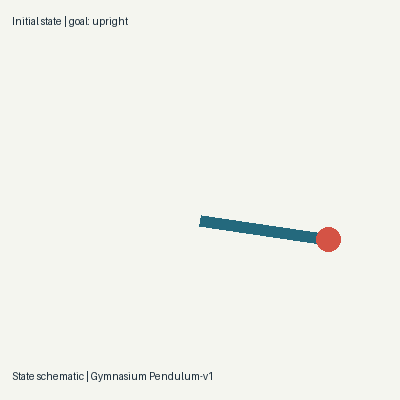

Reward formula agrees with simulator: -2.96468


In [4]:
env = gym.make("Pendulum-v1")
obs, _ = env.reset(seed=42)
display(pd.DataFrame({"feature": ["cos(theta)", "sin(theta)", "angular_velocity"], "value": obs}))
print("dt:", env.unwrapped.dt, "action bounds:", env.action_space.low, env.action_space.high)
display(pendulum_frame(obs, "Initial state | goal: upright"))
action = np.array([.5], dtype=np.float32)
theta = np.arctan2(obs[1], obs[0])
predicted_reward = -(theta**2 + .1*obs[2]**2 + .001*action[0]**2)
nxt, reward, terminated, truncated, _ = env.step(action)
np.testing.assert_allclose(reward, predicted_reward, atol=2e-6)
print("Reward formula agrees with simulator:", round(float(reward), 5))
env.close()

## 3 · 先建立 SAC，再理解它怎样得到训练信号

SAC 同时维护动作策略 actor、两套 Q 网络 critic 和慢更新的目标 Q 网络。Q 估计长期回报；动作策略追求较高 Q，并用熵项鼓励探索。两套 Q 与目标网络用于降低部分估计问题，不保证训练必然稳定。

这里使用 SB3 原实现，避免把实现 SAC 的工程量混进第一次问题定义。你可以直接查看实际网络、数据和更新次数。

Replay buffer 保存的是 $(o,a,r,o',terminated,truncated)$，**没有专家动作标签**。SAC 从历史交互中采样，反复更新模型；因此环境步数与梯度更新数是两个预算。

In [5]:
training_env = TransitionRecorder(gym.make("Pendulum-v1"))
model = SAC("MlpPolicy", training_env, policy_kwargs={"net_arch": [64, 64]},
            seed=SEED, device="cpu", verbose=0, buffer_size=TOTAL_STEPS + 1000,
            learning_starts=500, batch_size=128, learning_rate=1e-3,
            train_freq=1, gradient_steps=1, gamma=.99, ent_coef="auto")
model.set_logger(configure(str(OUT / "training"), ["csv"]))
print(model.policy.actor)

def checkpoint(name):
    model.save(OUT / name)
    with preserve_cpu_rng():
        loaded = SAC.load(OUT / name, device="cpu")
    probe = np.array([1., 0., 0.], dtype=np.float32)
    np.testing.assert_allclose(model.predict(probe, deterministic=True)[0],
                               loaded.predict(probe, deterministic=True)[0], atol=0, rtol=0)
    print(name, "save/reload PASS")
    return loaded

policies = {"sac_0": checkpoint("sac_0")}

Actor(
  (features_extractor): FlattenExtractor(
    (flatten): Flatten(start_dim=1, end_dim=-1)
  )
  (latent_pi): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
  )
  (mu): Linear(in_features=64, out_features=1, bias=True)
  (log_std): Linear(in_features=64, out_features=1, bias=True)
)
sac_0 save/reload PASS


## 4 · 第一阶段：交互数据从哪里来？

前 500 步用于随机探索，之后边采集边更新。训练时有探索，评测时使用确定性动作。
训练回报好坏还受探索策略和当时遇到的初始状态影响，不能直接当独立评测结果。

In [6]:
stage_start = time.perf_counter()
model.learn(total_timesteps=FIRST_STEPS, callback=Progress(), log_interval=1)
print("Actual environment steps:", model.num_timesteps, "seconds:", round(time.perf_counter()-stage_start, 2))
policies[f"sac_{FIRST_STEPS}"] = checkpoint(f"sac_{FIRST_STEPS}")
training_env.save(OUT / "raw_first_stage.npz")
with np.load(OUT / "raw_first_stage.npz") as loaded:
    raw = {k: loaded[k] for k in loaded.files}
display(pd.DataFrame([audit_transitions(raw)]))
display(pd.DataFrame({"episode": raw["episode"][:6], "step": raw["step"][:6],
                      "torque": raw["action"][:6, 0], "reward": raw["reward"][:6]}))
print("Fields:", list(raw))

Collected 2000 environment steps
Actual environment steps: 2000 seconds: 1.58
sac_2000 save/reload PASS


,rows,episodes,audit
0,2000,10,PASS


,episode,step,torque,reward
0,0,0,0.500382,-0.681155
1,0,1,1.588855,-0.931306
2,0,2,1.102743,-1.421004
3,0,3,-1.099171,-2.138244
4,0,4,-0.799335,-2.888121
5,0,5,1.494214,-3.916557


Fields: ['obs', 'action', 'next_obs', 'reward', 'terminated', 'truncated', 'episode', 'step']


## 5 · 找到一个非常实际的坑：动作尺度与时间截断

模拟器使用 [-2,2] 的动作；SB3 的 replay buffer 里动作缩放到 [-1,1]。字段同名不代表单位相同，导出数据或换框架时要显式转换。

`terminated` 指任务本身结束，`truncated` 指外部限制导致停止。Pendulum 的第 200 步是时间截断。
对于此处继续任务的价值估计，时间到了不等于下一状态价值为零。SB3 记录 timeout，在采样时使用 `done * (1-timeout)` 作为终止掩码。
下面检查真正写入 buffer 的记录，尤其是时间截断前的 next_obs 是否被错误换成 reset 后的初始观测。

In [6]:
buffer = model.replay_buffer
n = len(raw["obs"])
assert n < buffer.buffer_size  # 当前 buffer 未环绕，便于逐行核对
np.testing.assert_allclose(buffer.observations[:n, 0], raw["obs"], atol=1e-6)
np.testing.assert_allclose(buffer.next_observations[:n, 0], raw["next_obs"], atol=1e-6)
np.testing.assert_allclose(buffer.actions[:n, 0], model.policy.scale_action(raw["action"]), atol=1e-6)
cut = int(np.flatnonzero(raw["truncated"])[0])
done = float(buffer.dones[cut, 0]); timeout = float(buffer.timeouts[cut, 0])
effective_done = done * (1 - timeout)
assert effective_done == 0 and not raw["terminated"][cut]
display(pd.DataFrame([dict(row=cut, terminated=bool(raw["terminated"][cut]),
    truncated=bool(raw["truncated"][cut]), buffer_done=done, timeout=timeout,
    effective_done=effective_done)]))

# 数值示例，只演示终止掩码；5.0 不是实际 critic 估计，省略了 SAC 熵项。
toy_reward, toy_next_value = -1., 5.
print("Time limit target example:", toy_reward + .99 * (1-effective_done) * toy_next_value)
print("Incorrectly treating time limit as terminal:", toy_reward)

,row,terminated,truncated,buffer_done,timeout,effective_done
0,199,False,True,1.0,1.0,0.0


Time limit target example: 3.95
Incorrectly treating time limit as terminal: -1.0


**停下来复述**：如果只导出一个 `done` 列，你会丢失什么信息？如果把 scaled_action 当原始力矩执行，会有什么变化？

## 6 · 继续训练，记录真实预算

第二阶段沿用同一 actor、critic、优化器和 replay buffer，追加 `TOTAL_STEPS-FIRST_STEPS` 次交互。没有重建模型。
这里比较的是一条训练轨迹的不同预算点，不是多个独立训练样本。
加载评测用 checkpoint 时会临时初始化网络；辅助函数保存并恢复 CPU 随机数状态，避免“读取 checkpoint”本身改变后续训练的随机序列。

In [7]:
model.learn(total_timesteps=TOTAL_STEPS-FIRST_STEPS, reset_num_timesteps=False,
            callback=Progress(), log_interval=1)
assert model.num_timesteps == TOTAL_STEPS
policies[f"sac_{TOTAL_STEPS}"] = checkpoint(f"sac_{TOTAL_STEPS}")
training_env.save(OUT / "raw_experience.npz")
with np.load(OUT / "raw_experience.npz") as loaded:
    raw = {k: loaded[k] for k in loaded.files}
assert len(raw["obs"]) == TOTAL_STEPS
display(pd.DataFrame([audit_transitions(raw)]))
print("Raw arrays total:", round(sum(x.nbytes for x in raw.values())/1024**2, 2), "MiB")
training_env.close()

Collected 4000 environment steps
Collected 6000 environment steps
Collected 8000 environment steps
Collected 10000 environment steps
sac_10000 save/reload PASS


,rows,episodes,audit
0,10000,50,PASS


Raw arrays total: 0.51 MiB


,time/episodes,time/fps,time/time_elapsed,rollout/ep_len_mean,rollout/ep_rew_mean,time/total_timesteps,train/learning_rate,train/ent_coef,train/critic_loss,train/ent_coef_loss,train/n_updates,train/actor_loss
47,48,987,7,200.0,-503.235288,9600,0.001,0.087162,2.456263,0.172945,9099.0,65.003708
48,49,987,7,200.0,-497.840992,9800,0.001,0.085334,3.326165,-0.631420,9299.0,53.219112
49,50,987,8,200.0,-492.438606,10000,0.001,0.082114,3.292181,-0.390030,9499.0,57.717484


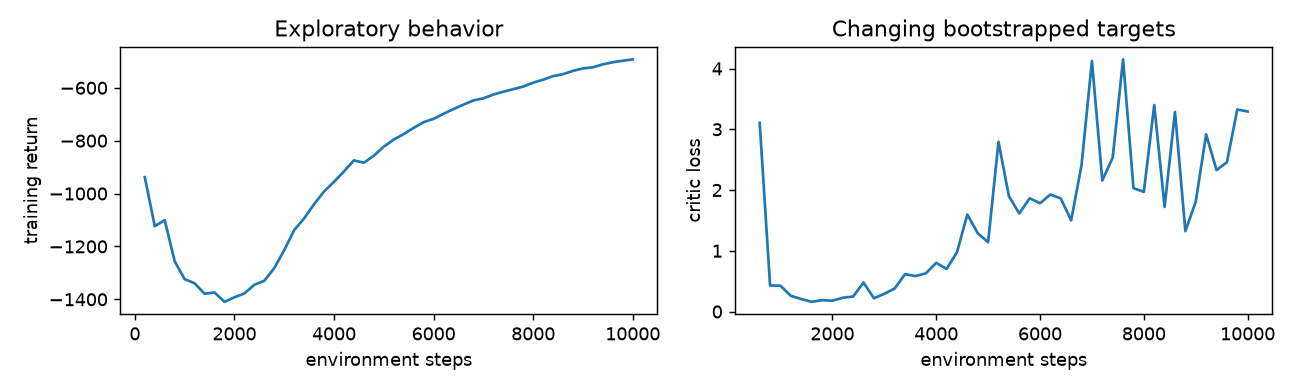

In [8]:
progress = pd.read_csv(OUT / "training/progress.csv")
display(progress.tail(3))
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(progress["time/total_timesteps"], progress["rollout/ep_rew_mean"])
axes[0].set(xlabel="environment steps", ylabel="training return", title="Exploratory behavior")
axes[1].plot(progress["time/total_timesteps"], progress["train/critic_loss"])
axes[1].set(xlabel="environment steps", ylabel="critic loss", title="Changing bootstrapped targets")
fig.tight_layout(); fig.savefig(OUT / "training_curves.png", dpi=130); plt.close(fig)
display(Image(filename=str(OUT / "training_curves.png")))

**读曲线**：critic 的目标由奖励、后续价值估计和策略共同决定，会随训练变化。它不像固定监督标签上的 MSE；“critic loss 不单调下降”本身不能判定失败。

## 7 · 冻结 checkpoint 后独立评测

随机策略、未训练策略、两个训练阶段使用相同的评测 seed，并记录每个 episode。
随机策略与未训练的确定性神经网络不是同一个基线。

三种场景分别评测：正常、100 ms 观测延迟、重力从 10 改到 12。改变重力时不同时加延迟，以免混淆原因。
随机动作不读取观测，因此单独加观测延迟不应改变它的结果，这也提供了评测器自检。

   policy   condition  n         mean       ci_low      ci_high
   random delay_0_g10 16 -1154.834265 -1259.357609 -1040.374678
    sac_0 delay_0_g10 16 -1372.586829 -1409.849296 -1329.109740
 sac_2000 delay_0_g10 16 -1201.803916 -1247.669865 -1150.728793
sac_10000 delay_0_g10 16  -113.716013  -158.747599   -68.687864
   random delay_2_g10 16 -1154.834265 -1260.506830 -1041.126989
    sac_0 delay_2_g10 16 -1372.632974 -1411.362128 -1326.665163
 sac_2000 delay_2_g10 16 -1423.901176 -1492.428870 -1355.824681
sac_10000 delay_2_g10 16  -126.698876  -173.028617   -81.071118
   random delay_0_g12 16 -1225.280493 -1324.699422 -1117.760957
    sac_0 delay_0_g12 16 -1273.322168 -1339.656178 -1216.360201
 sac_2000 delay_0_g12 16 -1288.268987 -1327.241765 -1249.369811
sac_10000 delay_0_g12 16  -124.880064  -169.267250   -75.239930


return  upright_fraction
policy    condition                              
random    delay_0_g10 -1154.834             0.013
          delay_0_g12 -1225.280             0.018
          delay_2_g10 -1154.834             0.013
sac_0     delay_0_g10 -1372.587             0.004
          delay_0_g12 -1273.322             0.004
          delay_2_g10 -1372.633             0.004
sac_10000 delay_0_g10  -113.716             0.877
          delay_0_g12  -124.880             0.865
          delay_2_g10  -126.699             0.852
sac_2000  delay_0_g10 -1201.804             0.011
          delay_0_g12 -1288.269             0.008
          delay_2_g10 -1423.901             0.013

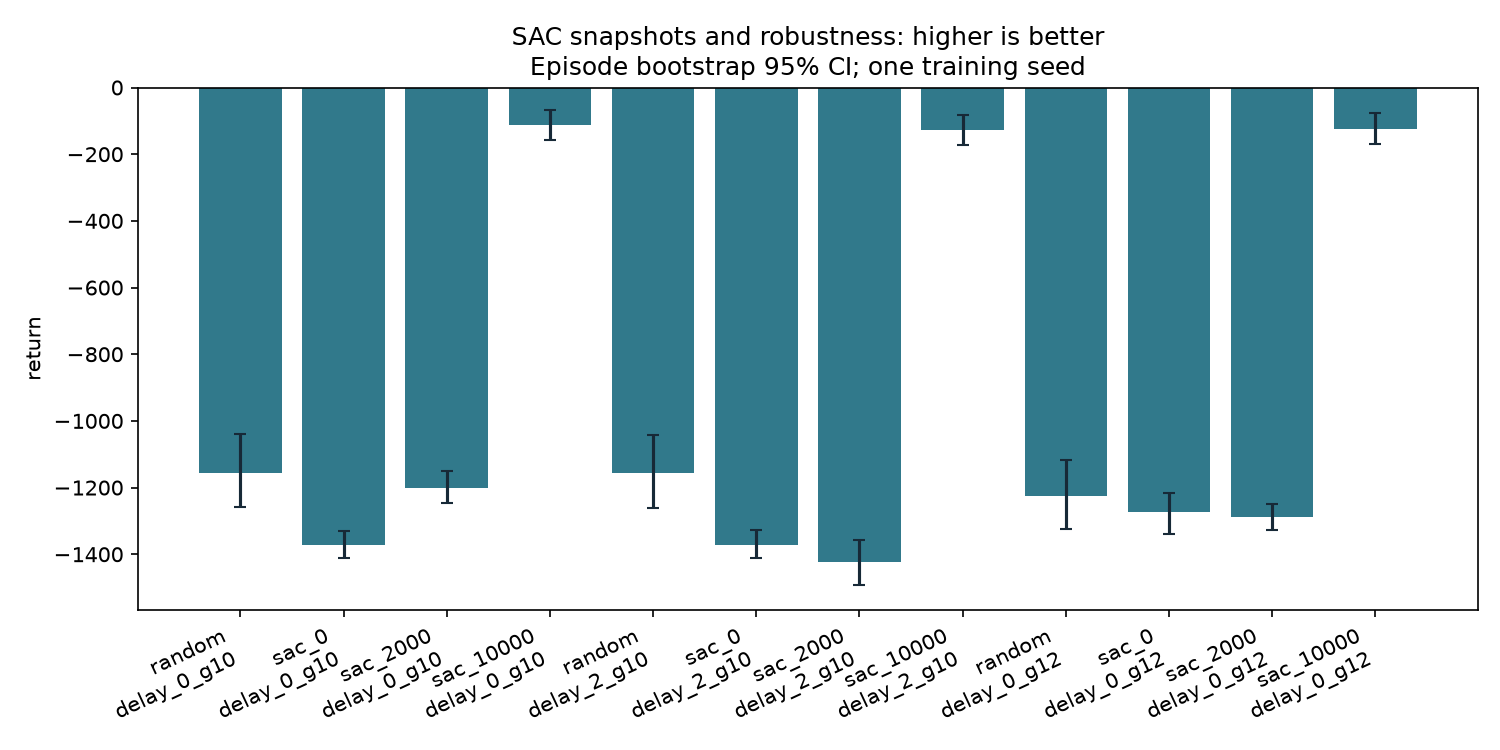

In [9]:
EVAL_SEEDS = list(range(10000, 10000+N_EVAL))
rows = []  # 重跑此格不会累积重复结果
for delay, gravity in [(0, 10.), (2, 10.), (0, 12.)]:
    rows += evaluate(None, "random", EVAL_SEEDS, delay, gravity, OUT)
    for name, policy in policies.items():
        rows += evaluate(policy, name, EVAL_SEEDS, delay, gravity, OUT)
frame = summarize(rows, OUT, "return", "SAC snapshots and robustness: higher is better")
display(frame.groupby(["policy", "condition"])[["return", "upright_fraction"]].mean().round(3))
display(Image(filename=str(OUT / "comparison.png")))
random_results = frame[frame.policy == "random"].pivot(index="seed", columns="condition", values="return")
np.testing.assert_array_equal(random_results["delay_0_g10"], random_results["delay_2_g10"])

,candidate,reference,condition,mean_delta,ci_low,ci_high,n_pairs
0,sac_10000,random,delay_0_g10,1041.118,946.008,1122.861,16
1,sac_10000,random,delay_0_g12,1100.400,1025.292,1167.693,16
2,sac_10000,random,delay_2_g10,1028.135,939.206,1107.537,16
3,sac_10000,sac_2000,delay_0_g10,1088.088,1063.954,1111.860,16
4,sac_10000,sac_2000,delay_0_g12,1163.389,1148.131,1179.303,16
5,sac_10000,sac_2000,delay_2_g10,1297.202,1253.947,1332.855,16


Delta > 0 means the final snapshot has higher return. These intervals condition on one training seed.


**sac_2000 · 同一个初始状态，真实仿真回放**


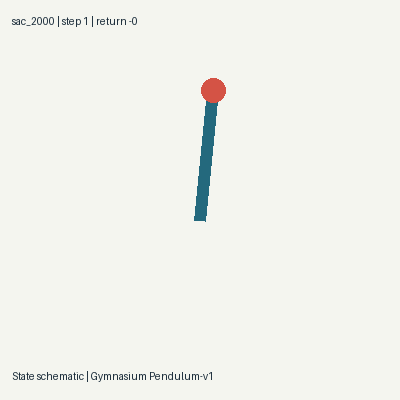

**sac_10000 · 同一个初始状态，真实仿真回放**


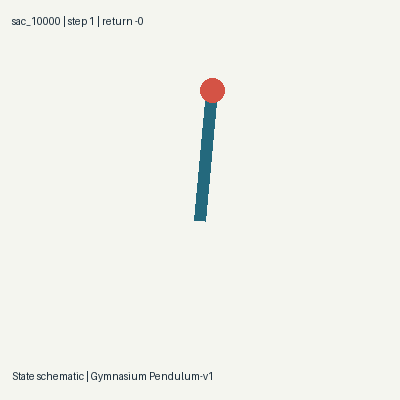

In [10]:
paired = pd.concat([paired_return(frame, f"sac_{TOTAL_STEPS}", reference)
                    for reference in ["random", f"sac_{FIRST_STEPS}"]], ignore_index=True)
paired.to_csv(OUT / "controlled_paired_deltas.csv", index=False)
display(paired.round(3))
print("Delta > 0 means the final snapshot has higher return. These intervals condition on one training seed.")
for name in [f"sac_{FIRST_STEPS}", f"sac_{TOTAL_STEPS}"]:
    display(Markdown(f"**{name} · 同一个初始状态，真实仿真回放**"))
    show_gif(OUT / f"{name}.gif")

## 8 · 复盘与下一轮

先回答，再读同目录 `02_参考复盘.md`。用实际表格引用数值，不写“模型应该变好了”。
回放只是一个初始状态，总体结论看完整分布；置信区间按 episode 重采样，但这里只有一个训练 seed。

In [11]:
MY_REVIEW = {
    "没有动作标签，更新信号从哪里来？": "待填写：解释 replay 中的一行怎样参与价值与策略更新。",
    "训练曲线与独立评测是否一致？": "待填写：引用至少两个数值，解释口径差异。",
    "哪个压力条件损害最大？": "待填写：正常/延迟/重力变化分别怎样？",
    "保存策略等于能够原样续训吗？": "待填写：讨论 replay、随机数状态与模拟器状态。",
    "下一轮只改变什么？": "待填写：假设、固定变量、评测标准。",
}
write_review(OUT, "SAC 学习闭环复盘", MY_PREDICTION, MY_REVIEW, frame, time.perf_counter()-START)

Elapsed from setup: 854.6 seconds (includes reading time in an interactive run).
Saved: runs/notebook02-20260913-163331-279000/review.md


## 9 · 第二遍作业与课件

1. 固定所有配置，换训练 seeds 7、11、19；按训练 seed 比较最终回报和压力测试，不把 16×200 帧当 3,200 个独立样本。
2. 冻结网络，选 5k/10k/20k 总预算，记录实际环境步数和墙钟耗时。多训练是否总是更好？
3. 再用 `loop02_reinforcement.py --algo ppo --steps 10000` 运行 PPO。它可能按完整 rollout 超出请求步数；对齐实际交互预算，也记录计算量，不能用一次小预算结果宣布算法优劣。
4. 假如要改奖励，必须在原始奖励和物理行为指标下复评，检查有没有“新分数更好、实际行为更差”。

下一课继续用同一个摆，但学习目标换成“预测下一状态”，动作交给规划器来选。

随用随读的一手资料：

- [Pendulum 环境合同](https://gymnasium.farama.org/environments/classic_control/pendulum/)：对应第 2 节。
- [SB3 SAC 文档](https://stable-baselines3.readthedocs.io/en/master/modules/sac.html)：对应第 3–6 节；安装版本由本项目锁文件决定。
- [SB3 时间截断处理源码](https://github.com/DLR-RM/stable-baselines3/blob/v2.9.0/stable_baselines3/common/buffers.py)：搜索 `handle_timeout_termination`，对应第 5 节。
- [SAC 原论文](https://arxiv.org/abs/1801.01290)：先读算法目标，再研究 critic/actor update。

可交付的小研究任务：给一个实际数据导出流程增加动作单位或 timeout 回归检查，证明它能捕获具体错误，再考虑贡献到相应项目。